# Chess Evaluations

References:
- Dataset: https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations/data
- Python-chess: https://www.kaggle.com/code/wlifferth/part-1-understanding-python-chess-and-fen
- Chess FEN: https://en.wikipedia.org/wiki/Forsyth%E2%80%93Edwards_Notation

In [1]:
import pandas as pd
import numpy as np
import chess
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.base import BaseEstimator
from IPython.display import display, Math

In [2]:
DATASET_FILE = "data/chessData.csv"
DATASET_SIZE = 10_000
FEN = "FEN"
EVAL = "Evaluation"
RANDOM_STATE = 99

In [3]:
dataframe = pd.read_csv(DATASET_FILE, nrows=5000)

In [4]:
EXAMPLE_GAME_ID = 50
EXAMPLE_FEN = dataframe["FEN"][EXAMPLE_GAME_ID]
EXAMPLE_FEN_FIELDS = EXAMPLE_FEN.split(" ")

labels = ["A","B","C","D","E","F"]

parts = [
    rf"\underbrace{{ \text{{{field}}} }}_{{ {label} }}"
    for field, label in zip(EXAMPLE_FEN_FIELDS, labels)
]

board = chess.Board(dataframe["FEN"][EXAMPLE_GAME_ID])

# FEN

Forsyth–Edwards Notation (FEN) is a standard notation for describing a particular board position of a chess game. The purpose of FEN is to provide all the necessary information to restart a game from a particular position.

A FEN record contains six fields, each separated by a space, e.g.:

<IPython.core.display.Math object>

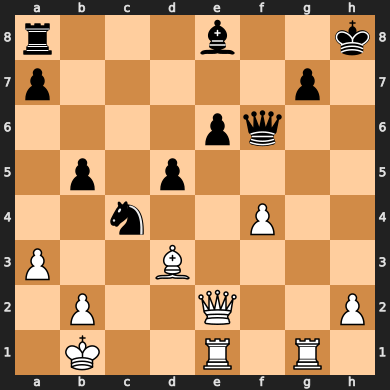

In [5]:
display(Math(r" \quad ".join(parts)))
display(board)

The fields are as follows:

- $A$: Piece placement
    - pawn = "P", knight = "N", bishop = "B", rook = "R", queen = "Q" and king = "K"
    - uppercase letters are white pieces, lowercase black pieces
    - digits from 1 to 8 indicate consecutive empty squares
    - for each rank (rank=row, 8 of them separated by "/") there are all the pieces described, starting from the a file (file=colum)
    - e.g.
- $B$: Active color: "w" for white to move, "b" for black
- $C$: [Castling](https://chess.fandom.com/wiki/Castling) availability
    - indicates which side (if any) can still castle (the right to castle can be lost once the king moves, something that you can't deduce from one single board position)
    - "K" for kingside castle, "Q" for queenside (lower case for black pieces), and "-" for none
- $D$: [En passant](https://chess.fandom.com/wiki/En_passant) target square
    - squares (in algebraic notation) over which a pawn has just passed while moving two squares
    - "-" for no squares
- $E$: Halfmove clock: number of halfmoves since the last capture or pawn advance (used for the [fifty-move rule](https://chess.fandom.com/wiki/Fifty_move_rule))
- $F$: Fullmove number: number of the moves since the beginning of the game

this whole project is about feature engineering, so extracting features from the FEN, blablabla...

# Cleaning

The evaluation feature is a string that contains the [centipawn evaluation](https://chess.fandom.com/wiki/Centipawn), and in the case of forced checkmate in less than 22 moves (the engine's depth), a hashtag is included at the beginning together with the number of moves. This is an edge-case, which is of no interest for our current goals. Moreover, these cases represent less than 1% of the dataset, which is already big enough, so we can just eliminate these rows.

Source: https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations/discussion/497472#2775858

In [6]:
dataframe[dataframe["Evaluation"].str[0] == "#"]

,FEN,Evaluation
59,7k/p1r2b2/4pq2/1p1p1nR1/5P2/P2B4/1P2Q2P/1K4R1 ...,#+6
60,7k/p1r2b2/4pq2/1p1p1BR1/5P2/P7/1P2Q2P/1K4R1 b ...,#+6
61,7k/p1r2b2/5q2/1p1p1pR1/5P2/P7/1P2Q2P/1K4R1 w -...,#+4
62,7k/p1r2b2/5q2/1p1p1p1R/5P2/P7/1P2Q2P/1K4R1 b -...,#+3
1440,7Q/8/4k3/p1p2p2/P7/1Pp1q1K1/6P1/8 w - - 3 64,#-19
1989,3r3k/p4Q2/3bp2p/2ppqp2/8/P1P3RP/1P3PP1/3R2K1 w...,#+5
1990,3r3k/p4Q2/3bp1Rp/2ppqp2/8/P1P4P/1P3PP1/3R2K1 b...,#+4
2561,6k1/p4p2/2b3pQ/5q2/2p5/P1P3R1/4r1PP/3Rn1K1 b -...,#-2
2562,6k1/p4p2/2b3pQ/8/2p5/P1P3R1/4rqPP/3Rn1K1 w - -...,#-1
3311,3q3r/5R2/7k/1b1pPp1p/p2P4/Q7/6PP/1r2BRK1 w - -...,#+8


In [7]:
dataframe = dataframe[~dataframe[EVAL].astype(str).str.contains("#")].copy()
dataframe[EVAL] = pd.to_numeric(dataframe[EVAL], errors="coerce").astype(int)

In [8]:
display(dataframe.dtypes[EVAL])
display(sum(dataframe[EVAL].isna()))

dtype('int64')

0

We also see the evaluation has a vast range of values, but most of them are accumulated around zero.

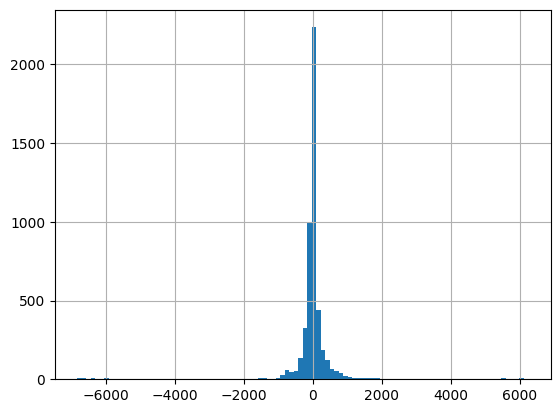

In [9]:
dataframe[EVAL].hist(bins=100)
plt.show()

So we want to either clip them to a maximum (say 1000) or consider them outliers and remove them from the training dataset. For now, we will consider the dataset clipped at 1000.

In [10]:
dataframe[EVAL] = np.clip(dataframe[EVAL], -1000, 1000)

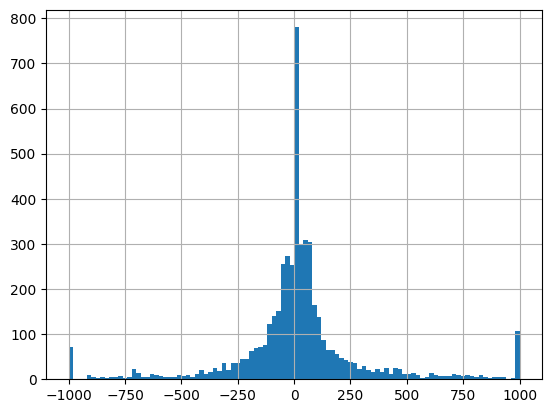

In [11]:
dataframe[EVAL].hist(bins=100)
plt.show()

# Evaluation Cleaner

In [12]:
class EvaluationCleaner:
    name = "Evaluation Cleaner"
    features = []

    @staticmethod
    def clean(df: pd.DataFrame, mode: str = "remove", threshold: int = 1000) -> pd.DataFrame:
        df = df[~df[EVAL].astype(str).str.contains("#")]
        df.loc[:, EVAL] = pd.to_numeric(df[EVAL], errors="coerce").astype(int)
        if mode == "clip":
            df.loc[:, EVAL] = np.clip(df[EVAL], -threshold, threshold)
        elif mode == "remove":
            df = df[df[EVAL].abs() <= threshold]
        else:
            raise ValueError("mode must be 'clip' or 'remove'")
        return df

# Data Manager

In [13]:
class DataManager:
    def __init__(self, filepath: str, read_size: int = 5_000_000, sample_size: int = 100_000, test_size: float = 0.2, random_state: int = 99, features: list = None, cleaner = EvaluationCleaner, transformers: list = None):
        self.filepath = filepath
        self.read_size = read_size
        self.sample_size = sample_size
        self.test_size = test_size
        self.random_state = random_state
        self.features = features or set()
        self.cleaner = cleaner
        self.transformers = transformers or []

        assert sample_size <= read_size, f"Sample size ({sample_size}) must be smaller than read size ({read_size})."

        self.df_all = pd.read_csv(filepath, nrows=read_size)
        self.df = None

        self.X = None
        self.y = None

        self.X_train = None
        self.X_test  = None
        self.y_train = None
        self.y_test  = None

        self.df_all = self.cleaner.clean(self.df_all)
        self.sample()

        if len(self.transformers) > 0:
            self.apply_transformers()
            self.train_test_split()

    def sample(self, sample_size: int = None):
        """Sample random rows."""
        if sample_size is not None:
            self.sample_size = sample_size
        self.df = self.df_all.sample(n=self.sample_size, random_state=self.random_state).reset_index(drop=True)
        self.X = self.df[[FEN]]
        self.y = self.df[EVAL]
        return self.df

    def apply_transformers(self, transformers: list = None):
        """Apply transformers to dataframe."""
        if transformers is not None:
            self.transformers = transformers
        if self.transformers is None:
            return self.X
        with tqdm(self.transformers, desc="Applying transformations", leave=False) as pbar:
            for transformer in pbar:
                if not transformer.features.issubset(self.features):
                    pbar.set_postfix({"transformer": transformer.name})
                    self.X = transformer.transform(self.X)
                    self.features.update(transformer.features)
        self.train_test_split()
        return self.X

    def train_test_split(self, features: list = None, test_size: float = None, random_state: int = None):
        """First sample then split."""
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X[list(features or self.features)],
            self.y,
            test_size=test_size or self.test_size,
            random_state=random_state or self.random_state
        )

        return self.X_train, self.X_test, self.y_train, self.y_test

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   FEN         10000 non-null  object
 1   Evaluation  10000 non-null  object
dtypes: object(2)
memory usage: 1.4 MB


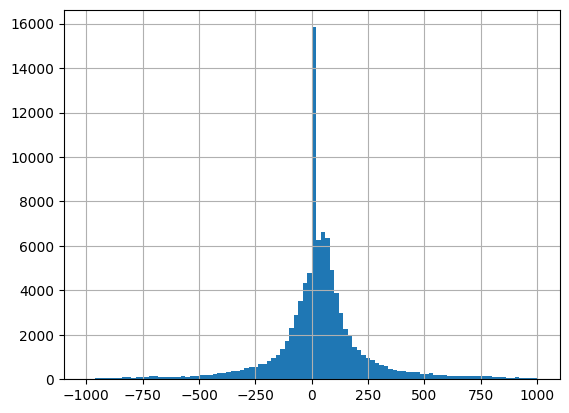

In [14]:
dm = DataManager(DATASET_FILE, sample_size=10_000, read_size=100_000, random_state=RANDOM_STATE)
DATAFRAME = dm.df
DATAFRAME.info(memory_usage="deep")
dm.df_all[EVAL].hist(bins=100)
plt.show()

# Chess Manager

In [15]:
class ChessManager:
    def __init__(self, dm: DataManager):
        self.dm = dm

    def show_board(self, idx: int):
        fen = self.dm.df.loc[idx, FEN]
        display(chess.Board(fen))

    def show_features(self, idx: int):
        display(self.dm.df.loc[idx])

    def show(self, idx: int):
        self.show_features(idx)
        self.show_board(idx)

FEN           r5k1/1p4p1/1n2p3/n2pP3/p2P4/P1N1P1r1/1P2b2N/4R...
Evaluation                                                   -6
Name: 100, dtype: object

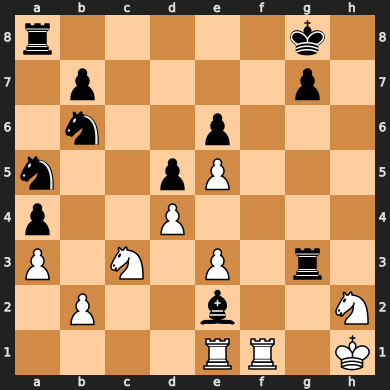

In [16]:
cm = ChessManager(dm)
cm.show(100)

# Number of Pieces

In [17]:
class PieceInfo:
    name = "Piece Information"
    features = set()
    methods = list()

    @staticmethod
    def extract_total_piece_count(dataframe: pd.DataFrame) -> pd.DataFrame:
        out = dataframe.copy()

        def count(fen):
            temp_board = chess.Board(fen)
            white = sum(1 for p in temp_board.piece_map().values() if p.color)
            black = sum(1 for p in temp_board.piece_map().values() if not p.color)
            return white, black

        w, b = zip(*out[FEN].apply(count))
        out["White_Pieces"] = w
        out["Black_Pieces"] = b

        return out

    @staticmethod
    def transform(dataframe: pd.DataFrame) -> pd.DataFrame:
        out = dataframe.copy()
        out.drop(columns=PieceInfo.features, inplace=True, errors="ignore")
        for method in PieceInfo.methods:
            out = method(out)
        return out

PieceInfo.features.update(("White_Pieces", "Black_Pieces"))
PieceInfo.methods.append(PieceInfo.extract_total_piece_count)

In [18]:
dm.apply_transformers([PieceInfo])

,FEN,White_Pieces,Black_Pieces
0,6r1/2R4p/2bp1p1K/4pP2/1pPkP1P1/1P1P1B2/8/8 b -...,9,8
1,1rbqr1k1/3n1pbp/pp1p2p1/2pP4/P3P1nN/1PN3PP/1BQ...,15,15
2,8/5pk1/7p/r5PP/5PK1/7R/8/8 b - - 2 105,5,4
3,r3r1k1/1b3pbp/1p2p1p1/p2pP3/2qP1P1B/P1N2R2/1P4...,13,13
4,8/5k2/4pp2/np6/4KPP1/1P6/8/2N5 b - - 3 34,5,5
...,...,...,...
9995,2kr4/4bp2/2pqb1p1/p2pN3/1p1P4/P2BP3/1PP3P1/2K1...,11,11
9996,3r1rk1/pbqnbppp/1p2pn2/2pp4/2P5/1P1PPNP1/PB1NQ...,16,16
9997,r2qbbk1/p5pn/1pp1r2p/2PpN3/1P1P2P1/2NQ1R1P/P4P...,14,13
9998,3r1rk1/pp3pb1/2n1b1pp/2pN4/4P2q/2NB4/PP3PPP/2R...,13,13


# Model Manager

In [19]:
class ModelManager:
    def __init__(self, model: BaseEstimator, dm: DataManager):
        self.model = model
        self.dm = dm
        self.y_pred = None

        self.fit()

    def fit(self):
        self.model.fit(self.dm.X_train, self.dm.y_train)

    def predict(self):
        self.y_pred = self.model.predict(self.dm.X_test)
        return self.y_pred

    def predict_fen(self, fen: str):
        df_fen = pd.DataFrame({FEN: [fen]})
        if self.dm.transformers is not None:
            with tqdm(self.dm.transformers, desc="Applying transformations", leave=False) as pbar:
                for transformer in pbar:
                    pbar.set_postfix({"transformer": transformer.name})
                    df_fen = transformer.transform(df_fen)
        return self.model.predict(df_fen.drop(FEN, axis=1))

In [20]:
mm = ModelManager(GradientBoostingRegressor(), dm)
mm.predict()
mm.predict_fen(EXAMPLE_FEN)

array([-18.9925989])

# Metrics Manager

In [21]:
class MetricsManager:
    def __init__(self, mm: ModelManager):
        self.mm = mm

    @property
    def y_true(self):
        return self.mm.dm.y_test

    @property
    def y_pred(self):
        return self.mm.y_pred

    def sign_accuracy(self):
        true_sign = np.sign(self.y_true)
        pred_sign = np.sign(self.y_pred)
        true_sign[true_sign == 0] = 0
        pred_sign[pred_sign == 0] = 0
        return np.mean(true_sign == pred_sign)

    def sign_recall(self, player: str = "white"):
        true_sign = np.sign(self.y_true)
        pred_sign = np.sign(self.y_pred)

        if player == "white":
            mask = true_sign > 0
        elif player == "black":
            mask = true_sign < 0
        elif player == "draw":
            mask = true_sign == 0
        else:
            raise ValueError("player must be 'white' or 'black'")

        if mask.sum() == 0:
            return np.nan

        return np.sum(pred_sign[mask] == true_sign[mask]) / np.sum(mask)

    def centipawn_accuracy(self, tol=200):
        return np.mean(np.abs(self.y_true - self.y_pred) <= tol)

    def plot_scatter(self):
        plt.figure(figsize=(10, 8))
        plt.scatter(self.y_true, self.y_pred, alpha=0.5)
        plt.xlabel("True Eval")
        plt.ylabel("Predicted Eval")
        plt.show()

    def report(self, tol=200):
        print("MSE:", mean_squared_error(self.y_true, self.y_pred))
        print("Sign accuracy:", self.sign_accuracy())
        print("White winning recall:", self.sign_recall("white"))
        print("Black winning recall:", self.sign_recall("black"))
        print("Draw recall:", self.sign_recall("draw"))
        print(f"Centipawn ±{tol} accuracy:", self.centipawn_accuracy(tol))

    def plot_eval(self, f1, f2):
        w_vals = np.linspace(self.mm.dm.df[f1].min(), self.mm.dm.df[f1].max(), 100)
        b_vals = np.linspace(self.mm.dm.df[f2].min(), self.mm.dm.df[f2].max(), 100)
        W, B = np.meshgrid(w_vals, b_vals)

        grid_df = pd.DataFrame({f1: W.ravel(), f2: B.ravel()})
        Z = self.mm.model.predict(grid_df).reshape(W.shape)

        plt.figure(figsize=(8,10))
        contour = plt.contourf(W, B, Z, levels=50, cmap="viridis")
        plt.colorbar(contour, label="Predicted Evaluation (centipawns)")

        zero_line = plt.contour(W, B, Z, levels=[0], colors="white")
        plt.clabel(zero_line, fmt="0", fontsize=10)

        plt.xlabel(f1)
        plt.ylabel(f2)
        plt.title("Predicted Evaluation")

        plt.show()

    def plot_tol_acc(self, max_tol=1000):
        tols = np.linspace(0, max_tol, 1000)
        accs = [self.centipawn_accuracy(tol) for tol in tols]

        auc = np.trapezoid(accs, tols) / max_tol

        plt.figure(figsize=(10, 8))
        plt.plot(tols, accs)
        plt.title(f"Tolerance-Accuracy Curve (AUC = {auc:.2f})")
        plt.xlabel("Centipawn Tolerance")
        plt.ylabel("Accuracy")
        plt.show()

MSE: 40582.785392762635
Sign accuracy: 0.5925
White winning recall: 0.9415467625899281
Black winning recall: 0.20783132530120482
Draw recall: 0.0
Centipawn ±200 accuracy: 0.8045


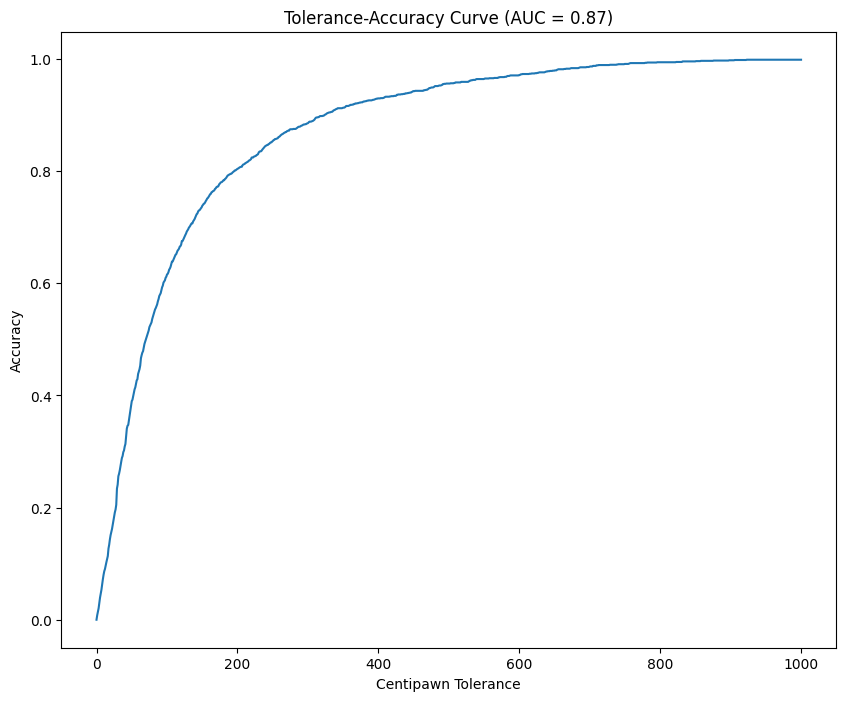

In [22]:
metm = MetricsManager(mm)
metm.report()
metm.plot_tol_acc()


# Basic Features

The most natural indicator that one would consider to predict the advantage of the players is the piece count: how many pieces does each player have. So, we code the first transformer to extract the piece count from the FEN.

Right away, we test our simple model with only these basic features. We will be considering a simple Random Forest and Linear Regressor.

Since the dataset is fairly balanced (54%-37), we will consider the plain sign accuracy of our prediction. For now, we are just checking the evaluation's sign because the RMSE is not yet a good indicator for model fitness.

## Piece values

Source: https://chess.fandom.com/wiki/Value

In [23]:
PIECE_VALUATIONS = {
    "standard": {
        chess.PAWN: 100,
        chess.KNIGHT: 300,
        chess.BISHOP: 300,
        chess.ROOK: 500,
        chess.QUEEN: 900,
        chess.KING: 0
    },
    "Jacob Sarratt's": {
        chess.PAWN: 100,
        chess.KNIGHT: 462,
        chess.BISHOP: 487,
        chess.ROOK: 750,
        chess.QUEEN: 1187,
        chess.KING: 0
    }
}

In [24]:
def extract_piece_values(dataframe: pd.DataFrame, valuation: str = "standard") -> pd.DataFrame:
    out = dataframe.copy()

    def piece_score(fen):
        temp_board = chess.Board(fen)
        white_score = 0
        black_score = 0

        for p in temp_board.piece_map().values():
            value = PIECE_VALUATIONS[valuation][p.piece_type]
            if p.color:
                white_score += value
            else:
                black_score += value

        return white_score, black_score

    w_val, b_val = zip(*dataframe[FEN].apply(piece_score))

    out["White_Piece_Value"] = w_val
    out["Black_Piece_Value"] = b_val

    return out

PieceInfo.features.update(("White_Piece_Value", "Black_Piece_Value"))
PieceInfo.extract_piece_values = staticmethod(extract_piece_values)
PieceInfo.methods.append(PieceInfo.extract_piece_values)

In [25]:
dm.apply_transformers([PieceInfo])

,FEN,White_Pieces,Black_Pieces,White_Piece_Value,Black_Piece_Value
0,6r1/2R4p/2bp1p1K/4pP2/1pPkP1P1/1P1P1B2/8/8 b -...,9,8,1400,1300
1,1rbqr1k1/3n1pbp/pp1p2p1/2pP4/P3P1nN/1PN3PP/1BQ...,15,15,3800,3800
2,8/5pk1/7p/r5PP/5PK1/7R/8/8 b - - 2 105,5,4,800,700
3,r3r1k1/1b3pbp/1p2p1p1/p2pP3/2qP1P1B/P1N2R2/1P4...,13,13,3200,3200
4,8/5k2/4pp2/np6/4KPP1/1P6/8/2N5 b - - 3 34,5,5,600,600
...,...,...,...,...,...
9995,2kr4/4bp2/2pqb1p1/p2pN3/1p1P4/P2BP3/1PP3P1/2K1...,11,11,2600,2600
9996,3r1rk1/pbqnbppp/1p2pn2/2pp4/2P5/1P1PPNP1/PB1NQ...,16,16,3900,3900
9997,r2qbbk1/p5pn/1pp1r2p/2PpN3/1P1P2P1/2NQ1R1P/P4P...,14,13,3500,3400
9998,3r1rk1/pp3pb1/2n1b1pp/2pN4/4P2q/2NB4/PP3PPP/2R...,13,13,3400,3400


MSE: 36893.122428118826
Sign accuracy: 0.603
White winning recall: 0.935251798561151
Black winning recall: 0.25
Draw recall: 0.0
Centipawn ±200 accuracy: 0.8155


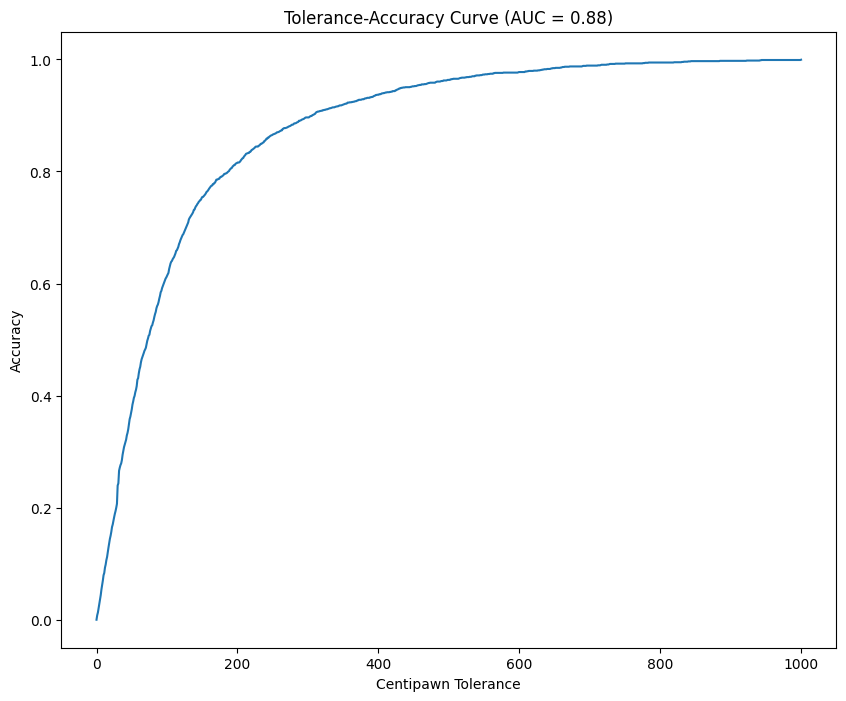

In [26]:
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()

## Number of Individual Piece Types

In [27]:
def extract_piece_count(dataframe: pd.DataFrame) -> pd.DataFrame:
    out = dataframe.copy()

    def count_types(fen):
        board = chess.Board(fen)
        piece_map = board.piece_map()

        # result dict { "White_PAWN": n, "Black_PAWN": n, ... }
        counts = {}

        for ptype in (
            chess.PAWN,
            chess.KNIGHT,
            chess.BISHOP,
            chess.ROOK,
            chess.QUEEN
        ):
            w = sum(1 for p in piece_map.values() if p.piece_type == ptype and p.color)
            b = sum(1 for p in piece_map.values() if p.piece_type == ptype and not p.color)
            counts[f"White_{chess.piece_name(ptype).capitalize()}"] = w
            counts[f"Black_{chess.piece_name(ptype).capitalize()}"] = b

        return counts

    feature_dicts = dataframe[FEN].apply(count_types)
    feature_df = pd.DataFrame(feature_dicts.tolist(), index=dataframe.index)

    out = pd.concat([out, feature_df], axis=1)
    return out

PieceInfo.features.update((
    "White_Pawn", "Black_Pawn",
    "White_Knight", "Black_Knight",
    "White_Bishop", "Black_Bishop",
    "White_Rook", "Black_Rook",
    "White_Queen", "Black_Queen"
))
PieceInfo.extract_piece_count = staticmethod(extract_piece_count)
PieceInfo.methods.append(PieceInfo.extract_piece_count)

In [28]:
dm.apply_transformers([PieceInfo])

,FEN,White_Pieces,Black_Pieces,White_Piece_Value,Black_Piece_Value,White_Pawn,Black_Pawn,White_Knight,Black_Knight,White_Bishop,Black_Bishop,White_Rook,Black_Rook,White_Queen,Black_Queen
0,6r1/2R4p/2bp1p1K/4pP2/1pPkP1P1/1P1P1B2/8/8 b -...,9,8,1400,1300,6,5,0,0,1,1,1,1,0,0
1,1rbqr1k1/3n1pbp/pp1p2p1/2pP4/P3P1nN/1PN3PP/1BQ...,15,15,3800,3800,7,7,2,2,2,2,2,2,1,1
2,8/5pk1/7p/r5PP/5PK1/7R/8/8 b - - 2 105,5,4,800,700,3,2,0,0,0,0,1,1,0,0
3,r3r1k1/1b3pbp/1p2p1p1/p2pP3/2qP1P1B/P1N2R2/1P4...,13,13,3200,3200,7,7,1,0,1,2,2,2,1,1
4,8/5k2/4pp2/np6/4KPP1/1P6/8/2N5 b - - 3 34,5,5,600,600,3,3,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2kr4/4bp2/2pqb1p1/p2pN3/1p1P4/P2BP3/1PP3P1/2K1...,11,11,2600,2600,6,6,1,0,1,2,1,1,1,1
9996,3r1rk1/pbqnbppp/1p2pn2/2pp4/2P5/1P1PPNP1/PB1NQ...,16,16,3900,3900,8,8,2,2,2,2,2,2,1,1
9997,r2qbbk1/p5pn/1pp1r2p/2PpN3/1P1P2P1/2NQ1R1P/P4P...,14,13,3500,3400,7,6,2,1,1,2,2,2,1,1
9998,3r1rk1/pp3pb1/2n1b1pp/2pN4/4P2q/2NB4/PP3PPP/2R...,13,13,3400,3400,6,6,2,1,1,2,2,2,1,1


MSE: 36465.4023096111
Sign accuracy: 0.6075
White winning recall: 0.927158273381295
Black winning recall: 0.27710843373493976
Draw recall: 0.0
Centipawn ±200 accuracy: 0.824


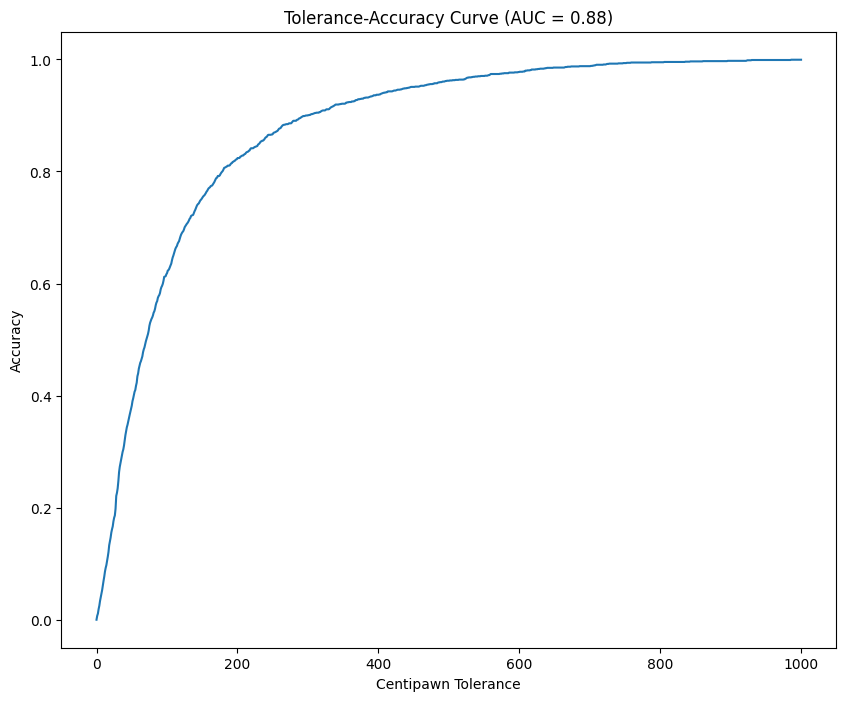

In [29]:
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()

In [30]:
importances = mm.model.feature_importances_
names = mm.dm.X.columns

ranked = sorted(zip(names, importances), key=lambda x: x[1], reverse=True)

for name, imp in ranked:
    print(name, imp)

White_Rook 0.3071686615684861
Black_Pawn 0.2536999866647195
White_Pawn 0.09826757908983567
Black_Rook 0.08343421640469509
Black_Bishop 0.0735688038456751
Black_Piece_Value 0.060901392568028484
White_Queen 0.029211199532502712
White_Knight 0.019183365007304887
FEN 0.01888499911500505
White_Piece_Value 0.01668271862655096
White_Bishop 0.014984818485407917
Black_Knight 0.012649559829142523
Black_Pieces 0.007375934481135892
White_Pieces 0.003986764781509951


### Extracting Piece's Valuations

In [31]:
mm_lr = ModelManager(LinearRegression(), dm)
mm_lr.predict()
metm.mm = mm_lr
metm.report()

MSE: 41114.19973021886
Sign accuracy: 0.5935
White winning recall: 0.8839928057553957
Black winning recall: 0.3072289156626506
Draw recall: 0.0
Centipawn ±200 accuracy: 0.804


In [32]:
coefs = pd.Series(mm_lr.model.coef_, index=dm.X_train.columns)
intercept = mm_lr.model.intercept_
piece_types = ["Pawn","Knight","Bishop","Rook","Queen"]

avg_abs = {}
for p in piece_types:
    cols = [c for c in coefs.index if p in c]
    vals = coefs[cols].abs()
    avg_abs[p] = vals.mean()

avg_abs = pd.Series(avg_abs)

pawn_val = avg_abs["Pawn"]
queen_val = avg_abs["Queen"]

scale = (900 - 100) / (queen_val - pawn_val)
shift = 100 - pawn_val * scale

normalized = avg_abs * scale + shift
normalized

Pawn       100.000000
Knight     671.245725
Bishop    1045.506648
Rook       908.156476
Queen      900.000000
dtype: float64

## Pawn Structure

In [33]:
class PawnStructure:
    name = "Pawn Structure"
    features = {"Isolated_Pawns_White", "Isolated_Pawns_Black", "Doubled_Pawns_White", "Doubled_Pawns_Black", "Passed_Pawns_White", "Passed_Pawns_Black"}

    @staticmethod
    def fen_to_file_counts(fen):
            temp_board = chess.Board(fen)
            white_counts = [0]*8
            black_counts = [0]*8
            for square in chess.SQUARES:
                piece = temp_board.piece_at(square)
                if piece is None:
                    continue
                file_idx = chess.square_file(square)
                if piece.piece_type == chess.PAWN:
                    if piece.color == chess.WHITE:
                        white_counts[file_idx] += 1
                    else:
                        black_counts[file_idx] += 1
            return white_counts, black_counts

    @staticmethod
    def isolated(pawn_counts):
            count = 0
            for i, c in enumerate(pawn_counts):
                if c == 0:
                    continue
                left = pawn_counts[i-1] if i > 0 else 0
                right = pawn_counts[i+1] if i < 7 else 0
                if left == 0 and right == 0:
                    count += c
            return count

    @staticmethod
    def doubled(pawn_counts):
        return sum(c-1 for c in pawn_counts if c > 1)

    @staticmethod
    def passed(own_counts, opp_counts):
            count = 0
            for i, c in enumerate(own_counts):
                if c == 0:
                    continue
                front_files = [i]
                if i > 0:
                    front_files.append(i-1)
                if i < 7:
                    front_files.append(i+1)
                blocked = any(opp_counts[f] > 0 for f in front_files)
                if not blocked:
                    count += c
            return count

    @classmethod
    def transform(cls, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()

        counts = df["FEN"].apply(lambda fen: cls.fen_to_file_counts(fen))
        white_counts = counts.apply(lambda x: x[0])
        black_counts = counts.apply(lambda x: x[1])

        out["Isolated_Pawns_White"] = white_counts.apply(cls.isolated)
        out["Isolated_Pawns_Black"] = black_counts.apply(cls.isolated)
        out["Doubled_Pawns_White"] = white_counts.apply(cls.doubled)
        out["Doubled_Pawns_Black"] = black_counts.apply(cls.doubled)
        out["Passed_Pawns_White"] = [cls.passed(w, b) for w, b in zip(white_counts, black_counts)]
        out["Passed_Pawns_Black"] = [cls.passed(b, w) for w, b in zip(white_counts, black_counts)]

        return out

In [34]:
dm.apply_transformers([PawnStructure])

,FEN,White_Pieces,Black_Pieces,White_Piece_Value,Black_Piece_Value,White_Pawn,Black_Pawn,White_Knight,Black_Knight,White_Bishop,...,White_Rook,Black_Rook,White_Queen,Black_Queen,Isolated_Pawns_White,Isolated_Pawns_Black,Doubled_Pawns_White,Doubled_Pawns_Black,Passed_Pawns_White,Passed_Pawns_Black
0,6r1/2R4p/2bp1p1K/4pP2/1pPkP1P1/1P1P1B2/8/8 b -...,9,8,1400,1300,6,5,0,0,1,...,1,1,0,0,0,2,0,0,0,0
1,1rbqr1k1/3n1pbp/pp1p2p1/2pP4/P3P1nN/1PN3PP/1BQ...,15,15,3800,3800,7,7,2,2,2,...,2,2,1,1,0,0,0,0,0,0
2,8/5pk1/7p/r5PP/5PK1/7R/8/8 b - - 2 105,5,4,800,700,3,2,0,0,0,...,1,1,0,0,0,2,0,0,0,0
3,r3r1k1/1b3pbp/1p2p1p1/p2pP3/2qP1P1B/P1N2R2/1P4...,13,13,3200,3200,7,7,1,0,1,...,2,2,1,1,0,0,0,0,0,0
4,8/5k2/4pp2/np6/4KPP1/1P6/8/2N5 b - - 3 34,5,5,600,600,3,3,1,1,0,...,0,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2kr4/4bp2/2pqb1p1/p2pN3/1p1P4/P2BP3/1PP3P1/2K1...,11,11,2600,2600,6,6,1,0,1,...,1,1,1,1,1,0,0,0,0,0
9996,3r1rk1/pbqnbppp/1p2pn2/2pp4/2P5/1P1PPNP1/PB1NQ...,16,16,3900,3900,8,8,2,2,2,...,2,2,1,1,0,0,0,0,0,0
9997,r2qbbk1/p5pn/1pp1r2p/2PpN3/1P1P2P1/2NQ1R1P/P4P...,14,13,3500,3400,7,6,2,1,1,...,2,2,1,1,0,0,0,0,0,0
9998,3r1rk1/pp3pb1/2n1b1pp/2pN4/4P2q/2NB4/PP3PPP/2R...,13,13,3400,3400,6,6,2,1,1,...,2,2,1,1,0,0,0,0,0,0


MSE: 41114.19973021886
Sign accuracy: 0.5935
White winning recall: 0.8839928057553957
Black winning recall: 0.3072289156626506
Draw recall: 0.0
Centipawn ±200 accuracy: 0.804


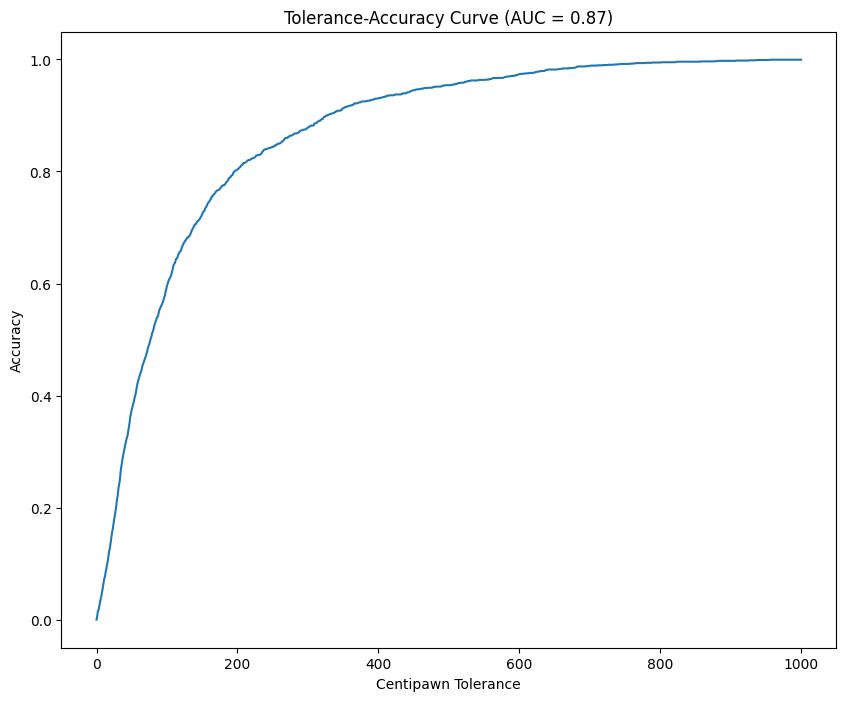

In [35]:
dm.train_test_split(list(PieceInfo.features | PawnStructure.features))
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()

## King Safety

In [36]:
class KingSafety:
    name = "King Safety"
    features = {"King_Castled_White", "King_Castled_Black", "King_Pawns_White", "King_Pawns_Black", "Open_Files"}

    @staticmethod
    def king_castled(fen, color):
        board = chess.Board(fen)
        k = board.king(color)
        if color == chess.WHITE:
            if k == chess.G1 and board.piece_at(chess.H1) == chess.Piece(chess.ROOK, chess.WHITE):
                return True
            if k == chess.C1 and board.piece_at(chess.A1) == chess.Piece(chess.ROOK, chess.WHITE):
                return True
        elif color == chess.BLACK:
            if k == chess.G8 and board.piece_at(chess.H8) == chess.Piece(chess.ROOK, chess.BLACK):
                return True
            if k == chess.C8 and board.piece_at(chess.A8) == chess.Piece(chess.ROOK, chess.BLACK):
                return True
        return False

    @staticmethod
    def king_pawns(fen, color):
        board = chess.Board(fen)
        sq = board.king(color)
        count = 0
        for df in [-1, 0, 1]:
            for dr in [-1, 0, 1]:
                if df == 0 and dr == 0:
                    continue
                f = chess.square_file(sq) + df
                r = chess.square_rank(sq) + dr
                if 0 <= f <= 7 and 0 <= r <= 7:
                    piece = board.piece_at(chess.square(f, r))
                    if piece and piece.piece_type == chess.PAWN and piece.color == color:
                        count += 1
        return count

    @staticmethod
    def open_files(fen):
        board = chess.Board(fen)
        count = 0
        for f in range(8):
            pawns_w = any(board.piece_at(chess.square(f, r)) == chess.Piece(chess.PAWN, chess.WHITE) for r in range(8))
            pawns_b = any(board.piece_at(chess.square(f, r)) == chess.Piece(chess.PAWN, chess.BLACK) for r in range(8))
            if not (pawns_w and pawns_b):
                count += 1
        return count

    @classmethod
    def transform(cls, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()

        out["King_Castled_White"] = df["FEN"].apply(lambda fen: cls.king_castled(fen, chess.WHITE))
        out["King_Castled_Black"] = df["FEN"].apply(lambda fen: cls.king_castled(fen, chess.BLACK))

        out["King_Pawns_White"] = df["FEN"].apply(lambda fen: cls.king_pawns(fen, chess.WHITE))
        out["King_Pawns_Black"] = df["FEN"].apply(lambda fen: cls.king_pawns(fen, chess.BLACK))

        out["Open_Files"] = df["FEN"].apply(cls.open_files)

        return out

In [37]:
dm.apply_transformers([KingSafety])

,FEN,White_Pieces,Black_Pieces,White_Piece_Value,Black_Piece_Value,White_Pawn,Black_Pawn,White_Knight,Black_Knight,White_Bishop,...,Isolated_Pawns_Black,Doubled_Pawns_White,Doubled_Pawns_Black,Passed_Pawns_White,Passed_Pawns_Black,King_Castled_White,King_Castled_Black,King_Pawns_White,King_Pawns_Black,Open_Files
0,6r1/2R4p/2bp1p1K/4pP2/1pPkP1P1/1P1P1B2/8/8 b -...,9,8,1400,1300,6,5,0,0,1,...,2,0,0,0,0,False,False,0,1,4
1,1rbqr1k1/3n1pbp/pp1p2p1/2pP4/P3P1nN/1PN3PP/1BQ...,15,15,3800,3800,7,7,2,2,2,...,0,0,0,0,0,False,False,1,2,2
2,8/5pk1/7p/r5PP/5PK1/7R/8/8 b - - 2 105,5,4,800,700,3,2,0,0,0,...,2,0,0,0,0,False,False,3,2,6
3,r3r1k1/1b3pbp/1p2p1p1/p2pP3/2qP1P1B/P1N2R2/1P4...,13,13,3200,3200,7,7,1,0,1,...,0,0,0,0,0,False,False,2,2,1
4,8/5k2/4pp2/np6/4KPP1/1P6/8/2N5 b - - 3 34,5,5,600,600,3,3,1,1,0,...,1,0,0,0,0,False,False,1,2,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2kr4/4bp2/2pqb1p1/p2pN3/1p1P4/P2BP3/1PP3P1/2K1...,11,11,2600,2600,6,6,1,0,1,...,0,0,0,0,0,False,False,2,0,3
9996,3r1rk1/pbqnbppp/1p2pn2/2pp4/2P5/1P1PPNP1/PB1NQ...,16,16,3900,3900,8,8,2,2,2,...,0,0,0,0,0,False,False,2,3,0
9997,r2qbbk1/p5pn/1pp1r2p/2PpN3/1P1P2P1/2NQ1R1P/P4P...,14,13,3500,3400,7,6,2,1,1,...,0,0,0,0,0,False,False,1,1,2
9998,3r1rk1/pp3pb1/2n1b1pp/2pN4/4P2q/2NB4/PP3PPP/2R...,13,13,3400,3400,6,6,2,1,1,...,0,0,0,0,0,False,False,3,1,3


MSE: 41114.19973021886
Sign accuracy: 0.5935
White winning recall: 0.8839928057553957
Black winning recall: 0.3072289156626506
Draw recall: 0.0
Centipawn ±200 accuracy: 0.804


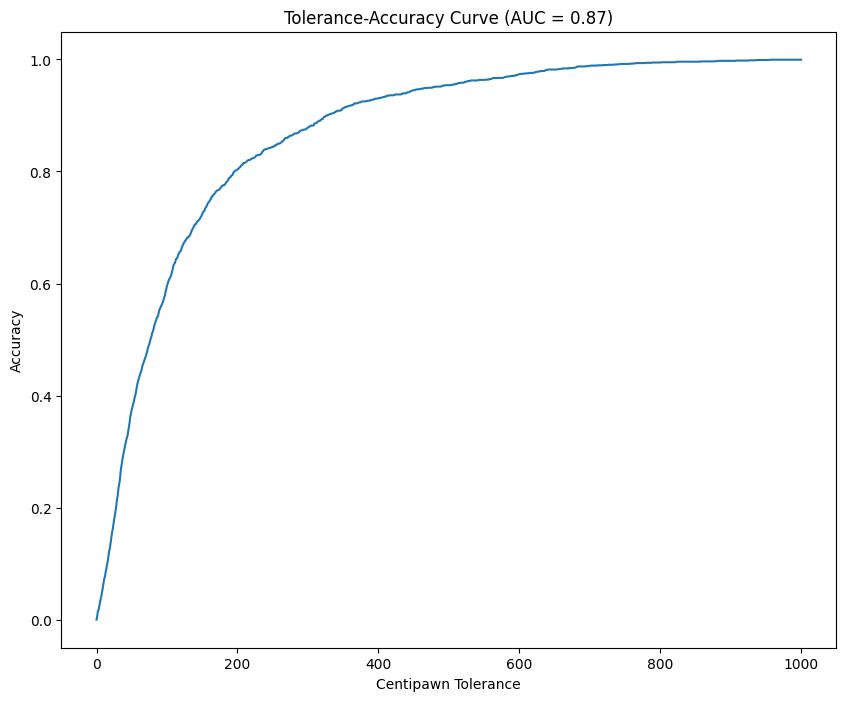

In [38]:
dm.train_test_split(list(PieceInfo.features | PawnStructure.features | KingSafety.features))
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()

---

# FULL

In [ ]:
dm = DataManager(
    filepath=DATASET_FILE,
    read_size=2_000_000,
    sample_size=500_000,
    transformers=[PieceInfo, PawnStructure, KingSafety],
)

In [ ]:
mm_gb = ModelManager(GradientBoostingRegressor(), dm)

In [ ]:
metm = MetricsManager(mm_gb)
metm.report()
metm.plot_tol_acc()
metm.plot_scatter()

In [ ]:
mm_lr = ModelManager(LinearRegression(), dm)

In [ ]:
mm_lr.predict()

metm = MetricsManager(mm_lr)
metm.report()
metm.plot_tol_acc()
metm.plot_scatter()

---

In [ ]:
# xat
PIECE_VALUES = {
    chess.PAWN: 1.0,
    chess.KNIGHT: 3.0,
    chess.BISHOP: 3.0,
    chess.ROOK: 5.0,
    chess.QUEEN: 9.0,
    chess.KING: 0.0
}

CENTRAL_SQUARES = {chess.E4, chess.D4, chess.E5, chess.D5}

def is_passed_pawn(board, square, color):
    file = chess.square_file(square)
    rank = chess.square_rank(square)
    if color == chess.WHITE:
        # any black pawn on same or adjacent file ahead (higher ranks)?
        for r in range(rank + 1, 8):
            for f in (file - 1, file, file + 1):
                if 0 <= f < 8:
                    sq = chess.square(f, r)
                    piece = board.piece_type_at(sq)
                    if piece == chess.PAWN and not board.color_at(sq):
                        return False
        return True
    else:
        # black pawn: look for white pawns ahead (lower ranks)
        for r in range(rank - 1, -1, -1):
            for f in (file - 1, file, file + 1):
                if 0 <= f < 8:
                    sq = chess.square(f, r)
                    piece = board.piece_type_at(sq)
                    if piece == chess.PAWN and board.color_at(sq):
                        return False
        return True

def pawn_stats(board, color):
    pawns = [sq for sq, piece in board.piece_map().items() if piece.piece_type == chess.PAWN and piece.color == color]
    files = {}
    doubled = 0
    isolated = 0
    passed = 0
    for sq in pawns:
        f = chess.square_file(sq)
        files.setdefault(f, 0)
        files[f] += 1
    doubled = sum(count - 1 for count in files.values() if count > 1)
    # isolated: file has pawns ==1 and no pawns on adjacent files
    for f, count in files.items():
        if count == 1 and files.get(f - 1, 0) == 0 and files.get(f + 1, 0) == 0:
            isolated += 1
    for sq in pawns:
        if is_passed_pawn(board, sq, color):
            passed += 1
    pawn_islands = 0
    sorted_files = sorted(files.keys())
    if sorted_files:
        prev = sorted_files[0] - 2
        for f in sorted_files:
            if f != prev + 1:
                pawn_islands += 1
            prev = f
    return {"doubled": doubled, "isolated": isolated, "passed": passed, "islands": pawn_islands}

def extract_features_from_fen(fen: str) -> dict:
    b = chess.Board(fen)
    features = {}
    # counts and material
    for color, prefix in ((chess.WHITE, "W_"), (chess.BLACK, "B_")):
        mat = 0.0
        for ptype in (chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING):
            cnt = len([1 for sq, pc in b.piece_map().items() if pc.piece_type == ptype and pc.color == color])
            features[f"{prefix}count_{ptype}"] = cnt
            mat += cnt * PIECE_VALUES[ptype]
        features[f"{prefix}material"] = mat
        # bishop pair
        features[f"{prefix}bishop_pair"] = int(features[f"{prefix}count_{chess.BISHOP}"] >= 2)
    # material diff and total
    features["mat_diff"] = features["W_material"] - features["B_material"]
    features["mat_total"] = features["W_material"] + features["B_material"]

    # mobility: legal moves for each side
    b_white = b.copy()
    b_white.turn = True
    features["mobility_white"] = len(list(b_white.legal_moves))
    b_black = b.copy()
    b_black.turn = False
    features["mobility_black"] = len(list(b_black.legal_moves))
    # mobility for side to move
    features["mobility_to_move"] = len(list(b.legal_moves))

    # king safety: attackers on king and in king zone
    wk_sq = b.king(chess.WHITE)
    bk_sq = b.king(chess.BLACK)
    features["W_king_attackers"] = 0 if wk_sq is None else len(b.attackers(chess.BLACK, wk_sq))
    features["B_king_attackers"] = 0 if bk_sq is None else len(b.attackers(chess.WHITE, bk_sq))
    # king zone attackers
    def king_zone_attackers(board, king_sq, attacker_color):
        if king_sq is None:
            return 0
        zone = [king_sq] + [n for n in chess.SQUARES if chess.square_distance(king_sq, n) == 1]
        return sum(len(board.attackers(attacker_color, sq)) for sq in zone)
    features["W_king_zone_attackers"] = king_zone_attackers(b, wk_sq, chess.BLACK)
    features["B_king_zone_attackers"] = king_zone_attackers(b, bk_sq, chess.WHITE)

    # pawn structure features
    pw = pawn_stats(b, chess.WHITE)
    pb = pawn_stats(b, chess.BLACK)
    for k, v in pw.items():
        features[f"W_pawn_{k}"] = v
    for k, v in pb.items():
        features[f"B_pawn_{k}"] = v

    # center control: attacks on central squares
    features["center_control_white"] = sum(1 for sq in CENTRAL_SQUARES if b.is_attacked_by(chess.WHITE, sq))
    features["center_control_black"] = sum(1 for sq in CENTRAL_SQUARES if b.is_attacked_by(chess.BLACK, sq))

    # central piece presence
    features["W_central_pieces"] = sum(1 for sq, pc in b.piece_map().items() if pc.color == chess.WHITE and sq in CENTRAL_SQUARES)
    features["B_central_pieces"] = sum(1 for sq, pc in b.piece_map().items() if pc.color == chess.BLACK and sq in CENTRAL_SQUARES)

    # castling rights and en-passant
    features["W_can_castle_kingside"] = int(b.has_kingside_castling_rights(chess.WHITE))
    features["W_can_castle_queenside"] = int(b.has_queenside_castling_rights(chess.WHITE))
    features["B_can_castle_kingside"] = int(b.has_kingside_castling_rights(chess.BLACK))
    features["B_can_castle_queenside"] = int(b.has_queenside_castling_rights(chess.BLACK))
    features["has_ep"] = int(b.ep_square is not None)
    features["in_check"] = int(b.is_check())

    # move counters / phase
    features["halfmove_clock"] = b.halfmove_clock
    features["fullmove_number"] = b.fullmove_number
    initial_total = sum(v * cnt for v, cnt in [
        (PIECE_VALUES[chess.PAWN], 16),
        (PIECE_VALUES[chess.KNIGHT], 4),
        (PIECE_VALUES[chess.BISHOP], 4),
        (PIECE_VALUES[chess.ROOK], 4),
        (PIECE_VALUES[chess.QUEEN], 2),
    ])
    features["phase"] = (features["mat_total"] / initial_total) if initial_total > 0 else 0.0

    # side to move
    features["side_to_move_white"] = int(b.turn)

    return features

rows = [extract_features_from_fen(fen) for fen in dm.df[FEN]]
X = pd.DataFrame(rows)
y = dm.df[EVAL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

dm2 = DataManager(DATASET_FILE, read_size=1, sample_size=1)
dm2.X_train, dm2.X_test, dm2.y_train, dm2.y_test = X_train, X_test, y_train, y_test
mm2 = ModelManager(GradientBoostingRegressor(), dm2)

In [ ]:
mm2.predict()

metm2 = MetricsManager(mm2)
metm2.report()
metm2.plot_tol_acc()
metm.plot_scatter()

sampling from 15_000_000:

- Mean Squared Error: 47108.02274584996
- Sign accuracy: 0.67685
- Positive sign recall: 0.8400834677036897
- Negative sign recall: 0.6334596643205198
- Centipawn ±200 accuracy: 0.76635

sampling from 200_00:

- Mean Squared Error: 29028.021170256125
- Sign accuracy: 0.66445
- Positive sign recall: 0.8580901856763926
- Negative sign recall: 0.5744510338195223
- Centipawn ±200 accuracy: 0.863